<a href="https://colab.research.google.com/github/debi201326/Shallow-and-Deep-Learning/blob/main/SDL_Practical_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implementing a Recurrent Neural Network for Sentiment Analysis of Movie Reviews (Internet Movie Database)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score
from math import sqrt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

In [ ]:
data = pd.read_csv("movie_reviews_large.csv")
print(" Sample Data:")
print(data.head())

 Sample Data:
                                     Review  Sentiment
0          Regret watching it, such a waste          0
1         Forgettable and meaningless movie          0
2         The plot was dull and predictable          0
3  Fantastic acting and brilliant direction          1
4               Disappointing and overhyped          0


In [ ]:
X = data['Review'].values
y = data['Sentiment'].values

In [ ]:
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X)
X_seq = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(X_seq, maxlen=60, padding='post')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42)

In [ ]:
model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=64, input_length=60))
model.add(SimpleRNN(128, activation='tanh', return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
history = model.fit(X_train, y_train, epochs=20, batch_size=4, validation_data=(X_test,
y_test), verbose=1)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6156 - loss: 0.6275 - val_accuracy: 0.9167 - val_loss: 0.3096
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9273 - loss: 0.2435 - val_accuracy: 1.0000 - val_loss: 0.0249
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9729 - loss: 0.0387 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 8.6556e-04
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 5.9520e-04
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 6.3962e-04 - val_accuracy: 1.0000 - val_loss: 4.6264e-04
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 5.1696e-04 - val_accuracy: 1.0000 - val_loss: 3.8390e-04
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 5.6559e-04 - v

In [ ]:
y_pred = model.predict(X_test)
y_pred_binary = [1 if val > 0.5 else 0 for val in y_pred]

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 492ms/step


In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = sqrt(mse)
acc = accuracy_score(y_test, y_pred_binary)
print("\n Mean Squared Error (MSE):", round(mse, 4))
print(" Root Mean Squared Error (RMSE):", round(rmse, 4))
print(" Accuracy:", round(acc * 100, 2), "%")


 Mean Squared Error (MSE): 0.0
 Root Mean Squared Error (RMSE): 0.0001
 Accuracy: 100.0 %


In [ ]:
results = pd.DataFrame({
'Actual Sentiment': y_test,
'Predicted Sentiment': y_pred_binary
})
print("\n Actual vs Predicted Sentiments:\n")
print(results.head(10))


 Actual vs Predicted Sentiments:

   Actual Sentiment  Predicted Sentiment
0                 0                    0
1                 0                    0
2                 0                    0
3                 0                    0
4                 0                    0
5                 1                    1
6                 0                    0
7                 1                    1
8                 0                    0
9                 0                    0


In [ ]:
def predict_review(review):
    seq = tokenizer.texts_to_sequences([review])
    padded_seq = pad_sequences(seq, maxlen=20, padding='post', truncating='post')
    pred = model.predict(padded_seq)[0][0]
    sentiment = "Positive" if pred > 0.5 else "Negative"
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment} (Score: {pred:.2f})\n")


predict_review("I really loved this movie, it was fantastic!")
predict_review("The movie was too slow and boring.")
predict_review("It had a few good scenes but overall disappointing.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Review: I really loved this movie, it was fantastic!
Predicted Sentiment: Positive (Score: 0.99)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Review: The movie was too slow and boring.
Predicted Sentiment: Negative (Score: 0.00)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Review: It had a few good scenes but overall disappointing.
Predicted Sentiment: Positive (Score: 0.92)



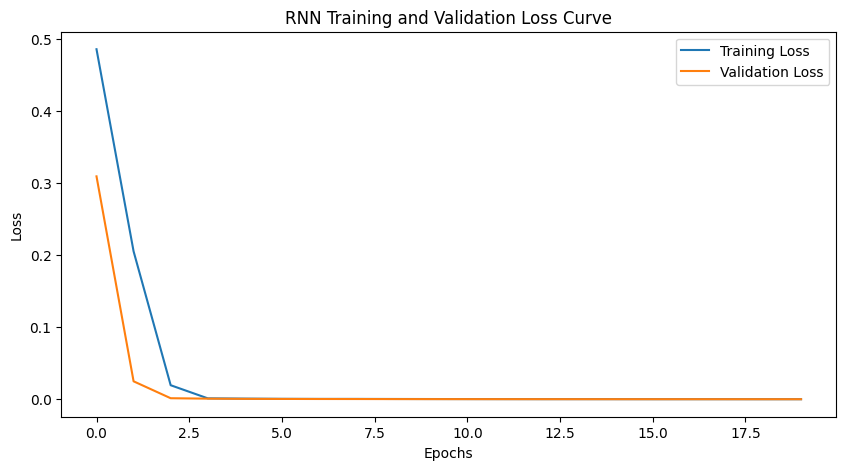

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("RNN Training and Validation Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()